<a href="https://colab.research.google.com/github/Meenarekha/Computer-Vision/blob/main/Histogram_Processing_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

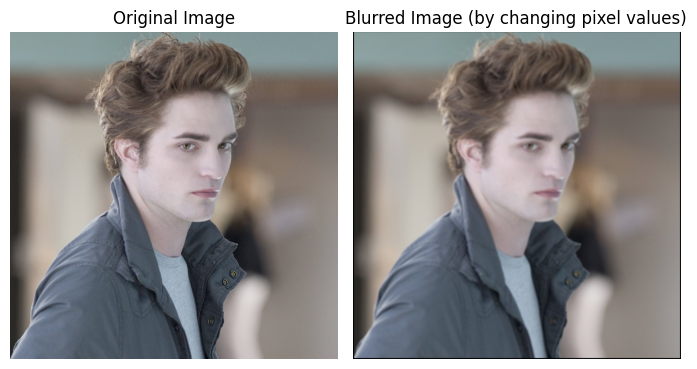

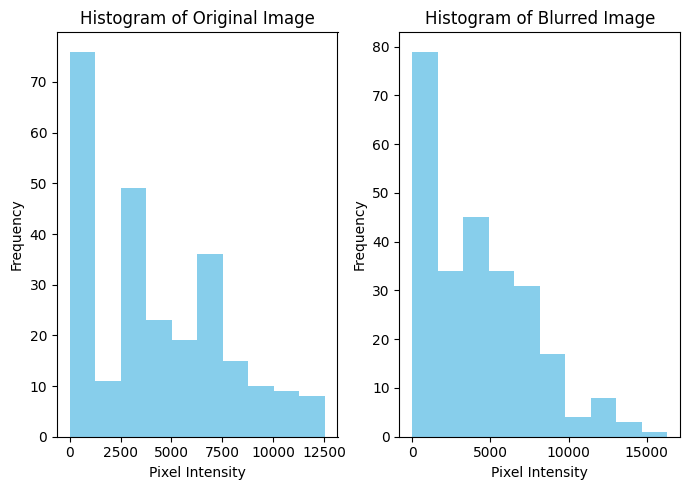

In [ ]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

image = cv2.imread(r"/content/actor.jpg")

height, width, channels = image.shape

blurred_image = np.zeros_like(image)

kernel_size = 7

kernel_radius = kernel_size // 2

for i in range(kernel_radius, height - kernel_radius):

    for j in range(kernel_radius, width - kernel_radius):

        for c in range(channels):

            region = image[i - kernel_radius:i + kernel_radius + 1, j - kernel_radius:j + kernel_radius + 1, c]

            blurred_image[i, j, c] = np.mean(region)

plt.figure(figsize=(7, 7))

plt.subplot(1, 2, 1)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.title('Original Image')

plt.axis('off')

plt.subplot(1, 2, 2)

plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))

plt.title('Blurred Image (by changing pixel values)')

plt.axis('off')

plt.tight_layout()

plt.show()


plt.figure(figsize=(7, 5))


histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
plt.subplot(1, 2, 1)
plt.hist(histogram,color='skyblue')
plt.title('Histogram of Original Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

histogram = cv2.calcHist([blurred_image], [0], None, [256], [0, 256])
plt.subplot(1, 2, 2)
plt.hist(histogram.ravel(),color='skyblue')
plt.title('Histogram of Blurred Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.tight_layout()

plt.show()

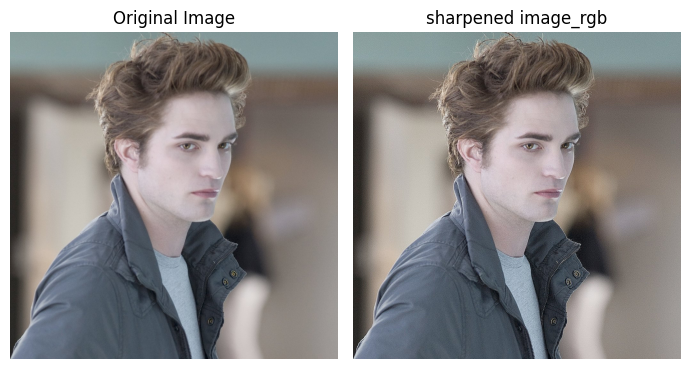

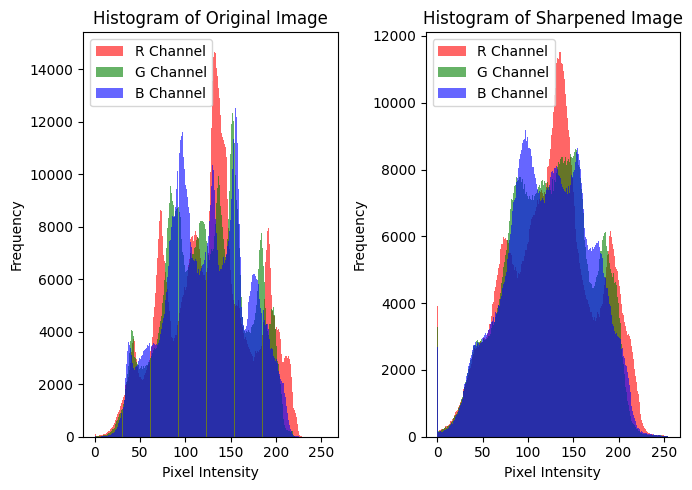

In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sharpening_kernel = np.array([[0, -1, 0],

                              [-1, 5, -1],

                              [0, -1, 0]])

sharpened_image = cv2.filter2D(image, -1, sharpening_kernel)

sharpened_image_rgb = cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 5))

plt.subplot(1, 2, 1)

plt.imshow(image_rgb)

plt.title('Original Image')

plt.axis('off')

plt.subplot(1, 2, 2)

plt.imshow(sharpened_image_rgb)
plt.title('sharpened image_rgb')
plt.axis('off')

plt.tight_layout()

plt.show()

def plot_histogram(image, ax, title):



    colors = ['r', 'g', 'b']

    for i, color in enumerate(colors):

        ax.hist(image[:, :, i].flatten(), bins=256, color=color, alpha=0.6, label=f'{color.upper()} Channel')



    ax.set_title(title)

    ax.set_xlabel('Pixel Intensity')

    ax.set_ylabel('Frequency')

    ax.legend()



fig, axes = plt.subplots(1, 2, figsize=(7, 5))

plot_histogram(image_rgb, axes[0], 'Histogram of Original Image')

plot_histogram(sharpened_image_rgb, axes[1], 'Histogram of Sharpened Image')

plt.tight_layout()

plt.show()

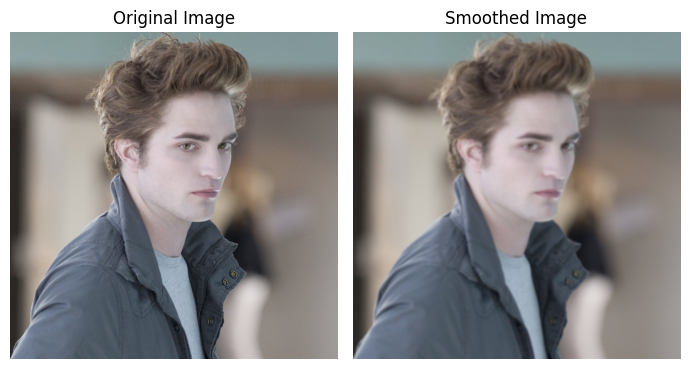

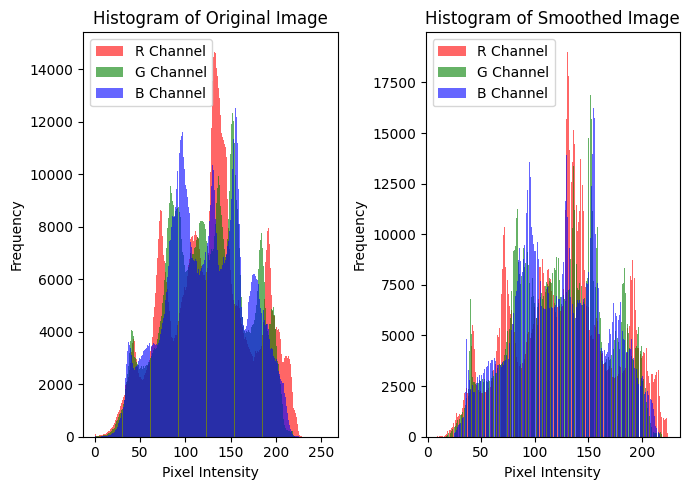

In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

smoothed_image = cv2.GaussianBlur(image, (15, 15), 0)

smoothed_image_rgb = cv2.cvtColor(smoothed_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 5))

plt.subplot(1, 2, 1)

plt.imshow(image_rgb)

plt.title('Original Image')

plt.axis('off')

plt.subplot(1, 2, 2)

plt.imshow(smoothed_image_rgb)

plt.title('Smoothed Image')

plt.axis('off')



plt.tight_layout()

plt.show()

def plot_histogram(image, ax, title):

    colors = ['r', 'g', 'b']

    for i, color in enumerate(colors):

        ax.hist(image[:, :, i].flatten(), bins=256, color=color, alpha=0.6, label=f'{color.upper()} Channel')



    ax.set_title(title)

    ax.set_xlabel('Pixel Intensity')

    ax.set_ylabel('Frequency')

    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(7,5))

plot_histogram(image_rgb, axes[0], 'Histogram of Original Image')

plot_histogram(smoothed_image_rgb, axes[1], 'Histogram of Smoothed Image')

plt.tight_layout()

plt.show()

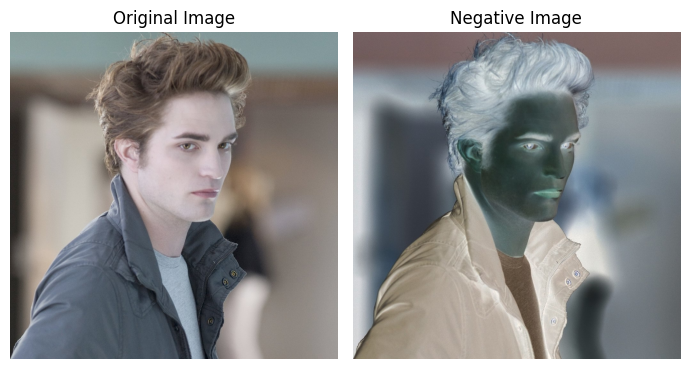

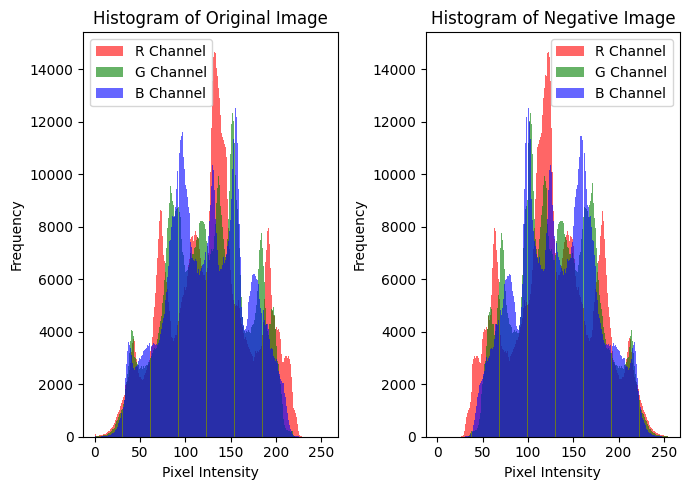

In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

negative_image = 255 - image

negative_image_rgb = cv2.cvtColor(negative_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 5))

plt.subplot(1, 2, 1)

plt.imshow(image_rgb)

plt.title('Original Image')

plt.axis('off')

plt.subplot(1, 2, 2)

plt.imshow(negative_image_rgb)

plt.title('Negative Image')

plt.axis('off')



plt.tight_layout()

plt.show()

def plot_histogram(image, ax, title):

    colors = ['r', 'g', 'b']

    for i, color in enumerate(colors):

        ax.hist(image[:, :, i].flatten(), bins=256, color=color, alpha=0.6, label=f'{color.upper()} Channel')



    ax.set_title(title)

    ax.set_xlabel('Pixel Intensity')

    ax.set_ylabel('Frequency')

    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(7, 5))

plot_histogram(image_rgb, axes[0], 'Histogram of Original Image')

plot_histogram(negative_image_rgb, axes[1], 'Histogram of Negative Image')

plt.tight_layout()

plt.show()

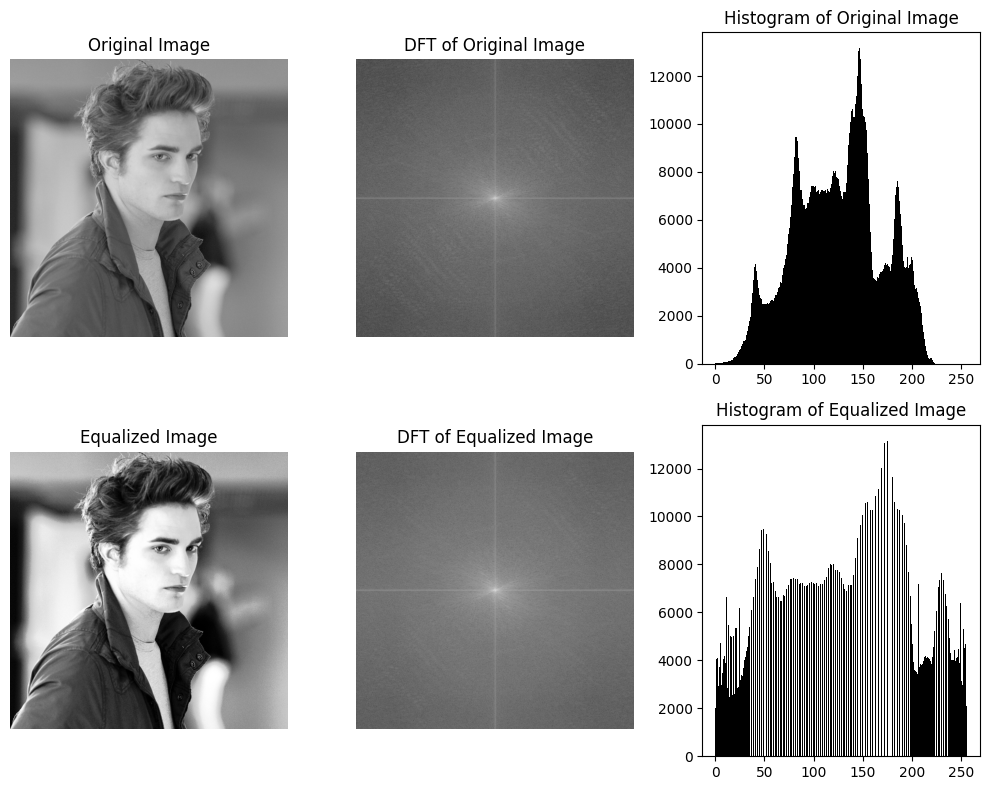

In [ ]:
image = cv2.imread(r"/content/actor.jpg", cv2.IMREAD_GRAYSCALE)

equalized_image = cv2.equalizeHist(image)

dft_original = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)

dft_original_shifted = np.fft.fftshift(dft_original)

magnitude_original = cv2.magnitude(dft_original_shifted[:,:,0], dft_original_shifted[:,:,1])

magnitude_original_log = np.log(magnitude_original + 1)

dft_equalized = cv2.dft(np.float32(equalized_image), flags=cv2.DFT_COMPLEX_OUTPUT)

dft_equalized_shifted = np.fft.fftshift(dft_equalized)

magnitude_equalized = cv2.magnitude(dft_equalized_shifted[:,:,0], dft_equalized_shifted[:,:,1])

magnitude_equalized_log = np.log(magnitude_equalized + 1)

plt.figure(figsize=(10, 8))

plt.subplot(2, 3, 1)

plt.imshow(image, cmap='gray')

plt.title('Original Image')

plt.axis('off')

plt.subplot(2, 3, 2)

plt.imshow(magnitude_original_log, cmap='gray')

plt.title('DFT of Original Image')

plt.axis('off')

plt.subplot(2, 3, 3)

plt.hist(image.ravel(), bins=256, range=(0, 256), color='black')

plt.title('Histogram of Original Image')

plt.subplot(2, 3, 4)

plt.imshow(equalized_image, cmap='gray')

plt.title('Equalized Image')

plt.axis('off')

plt.subplot(2, 3, 5)

plt.imshow(magnitude_equalized_log, cmap='gray')

plt.title('DFT of Equalized Image')

plt.axis('off')

plt.subplot(2, 3, 6)

plt.hist(equalized_image.ravel(), bins=256, range=(0, 256), color='black')

plt.title('Histogram of Equalized Image')

plt.tight_layout()

plt.show()